In [29]:
import pandas as pd
import numpy as np 

In [30]:
# load data from https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv
df = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv")
df.head()

,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3650 non-null   object 
 1   Temp    3650 non-null   float64
dtypes: float64(1), object(1)
memory usage: 57.2+ KB


In [32]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

In [33]:
df.head()

,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


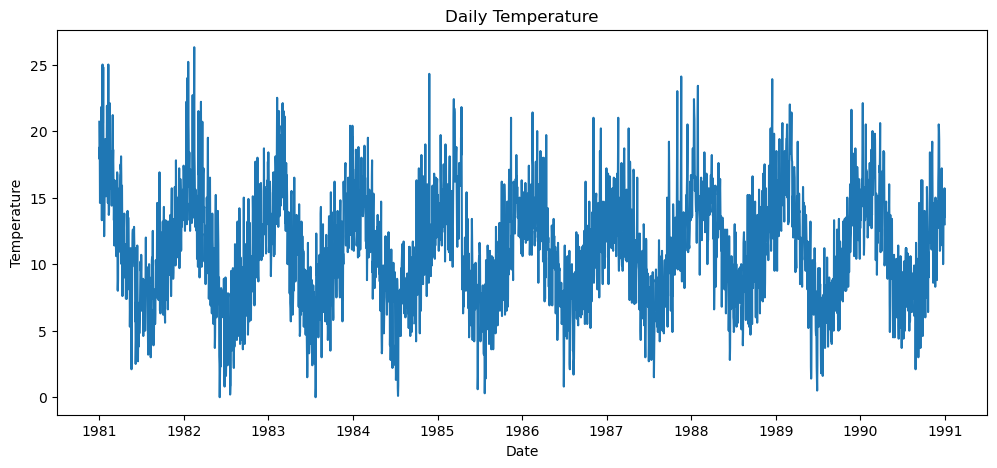

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df['Temp'])
plt.title("Daily Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.show()

In [35]:
# scale data 
from sklearn.preprocessing import MinMaxScaler
scaler =MinMaxScaler(feature_range=(0,1))

scaled_Data = scaler.fit_transform(df[['Temp']])

In [36]:
# create data set
def create_dataset(data, time_step =30):
    X, y = [], []

    for i in range(len(data) - time_step):
        X.append(data[i:i+time_step, 0])
        y.append(data[time_step + i, 0])

    return np.array(X), np.array(y)

time_step = 30

X, y = create_dataset(scaled_Data, time_step)

In [37]:
X.shape, y.shape

((3620, 30), (3620,))

In [39]:
for i in range(3):
    print(f"Sequence {i}")
    print(X[i])
    print("Target:", y[i])
    print()

Sequence 0
[0.78707224 0.68060837 0.7148289  0.55513308 0.60076046 0.60076046
 0.60076046 0.66159696 0.82889734 0.76045627 0.61596958 0.50570342
 0.63498099 0.81749049 0.95057034 0.78707224 0.78326996 0.94296578
 0.6730038  0.58935361 0.69201521 0.46007605 0.54752852 0.60836502
 0.62737643 0.71102662 0.73764259 0.6539924  0.58935361 0.57414449]
Target: 0.5855513307984791

Sequence 1
[0.68060837 0.7148289  0.55513308 0.60076046 0.60076046 0.60076046
 0.66159696 0.82889734 0.76045627 0.61596958 0.50570342 0.63498099
 0.81749049 0.95057034 0.78707224 0.78326996 0.94296578 0.6730038
 0.58935361 0.69201521 0.46007605 0.54752852 0.60836502 0.62737643
 0.71102662 0.73764259 0.6539924  0.58935361 0.57414449 0.58555133]
Target: 0.5817490494296578

Sequence 2
[0.7148289  0.55513308 0.60076046 0.60076046 0.60076046 0.66159696
 0.82889734 0.76045627 0.61596958 0.50570342 0.63498099 0.81749049
 0.95057034 0.78707224 0.78326996 0.94296578 0.6730038  0.58935361
 0.69201521 0.46007605 0.54752852 0.608

In [40]:
# train test split
train_size = int(len(X) * 0.8)
X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [43]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(2896, 30) (2896,)
(724, 30) (724,)


In [58]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(X_train.shape)
print(X_test.shape)

torch.Size([2896, 30, 1])
torch.Size([724, 30, 1])


In [59]:
import torch

X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train)

X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test)

print(X_train.shape)

torch.Size([2896, 30, 1])


In [60]:
from torch.utils.data import TensorDataset, DataLoader 

train_dataset = TensorDataset(X_train, y_train)

train_loader = DataLoader(
    train_dataset, 
    batch_size = 32,
    shuffle=True
)

In [61]:
train_loader.shape

AttributeError: 'DataLoader' object has no attribute 'shape'

In [62]:
# LSTM
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size = input_size,
            hidden_size=hidden_size, 
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)

        out = out[:, -1, :] 
        out = self.fc(out)

        return out

In [63]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

lstm_model = LSTMModel().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    lstm_model.parameters(),
    lr=0.001
)

In [64]:
EPOCHS = 20

for epoch in range(EPOCHS):

    lstm_model.train()

    epoch_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = lstm_model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Loss: {epoch_loss/len(train_loader):.6f}"
    )

/home/mohsinkhan/.local/lib/python3.14/site-packages/torch/nn/modules/loss.py:634: UserWarning: Using a target size (torch.Size([32])) that is different to the input size (torch.Size([32, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/home/mohsinkhan/.local/lib/python3.14/site-packages/torch/nn/modules/loss.py:634: UserWarning: Using a target size (torch.Size([16])) that is different to the input size (torch.Size([16, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch [1/20] Loss: 0.031183
Epoch [2/20] Loss: 0.023554
Epoch [3/20] Loss: 0.023601
Epoch [4/20] Loss: 0.023476
Epoch [5/20] Loss: 0.023408
Epoch [6/20] Loss: 0.023370
Epoch [7/20] Loss: 0.023453
Epoch [8/20] Loss: 0.023691
Epoch [9/20] Loss: 0.023517
Epoch [10/20] Loss: 0.023361
Epoch [11/20] Loss: 0.023501
Epoch [12/20] Loss: 0.023407
Epoch [13/20] Loss: 0.023473
Epoch [14/20] Loss: 0.023364
Epoch [15/20] Loss: 0.023552
Epoch [16/20] Loss: 0.023474
Epoch [17/20] Loss: 0.023488
Epoch [18/20] Loss: 0.023478
Epoch [19/20] Loss: 0.023472
Epoch [20/20] Loss: 0.023276


In [65]:
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):

        out, _ = self.gru(x)

        out = out[:, -1, :]

        out = self.fc(out)

        return out

In [66]:
gru_model = GRUModel().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    gru_model.parameters(),
    lr=0.001
)

for epoch in range(EPOCHS):

    gru_model.train()

    epoch_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = gru_model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Loss: {epoch_loss/len(train_loader):.6f}"
    )

Epoch [1/20] Loss: 0.028796
Epoch [2/20] Loss: 0.023478
Epoch [3/20] Loss: 0.023618
Epoch [4/20] Loss: 0.023550
Epoch [5/20] Loss: 0.023539
Epoch [6/20] Loss: 0.023853
Epoch [7/20] Loss: 0.023479
Epoch [8/20] Loss: 0.024079
Epoch [9/20] Loss: 0.023694
Epoch [10/20] Loss: 0.023448
Epoch [11/20] Loss: 0.023630
Epoch [12/20] Loss: 0.023500
Epoch [13/20] Loss: 0.023797
Epoch [14/20] Loss: 0.023386
Epoch [15/20] Loss: 0.023699
Epoch [16/20] Loss: 0.023662
Epoch [17/20] Loss: 0.023401
Epoch [18/20] Loss: 0.023867
Epoch [19/20] Loss: 0.023525
Epoch [20/20] Loss: 0.023578


In [36]:
from sklearn.metrics import mean_squared_error
import numpy as np

lstm_model.eval()

with torch.no_grad():

    lstm_pred = lstm_model(
        X_test.to(device)
    ).cpu().numpy()

gru_model.eval()

with torch.no_grad():

    gru_pred = gru_model(
        X_test.to(device)
    ).cpu().numpy()

In [39]:
lstm_pred = scaler.inverse_transform(lstm_pred)

gru_pred = scaler.inverse_transform(gru_pred)

actual = scaler.inverse_transform(
    y_test.numpy().reshape(-1, 1)
)

In [38]:
print(y_test.shape)

torch.Size([724])


In [40]:
lstm_rmse = np.sqrt(
    mean_squared_error(actual, lstm_pred)
)

gru_rmse = np.sqrt(
    mean_squared_error(actual, gru_pred)
)

print("LSTM RMSE:", lstm_rmse)
print("GRU RMSE :", gru_rmse)

LSTM RMSE: 279.83721551555647
GRU RMSE : 276.5337202539683


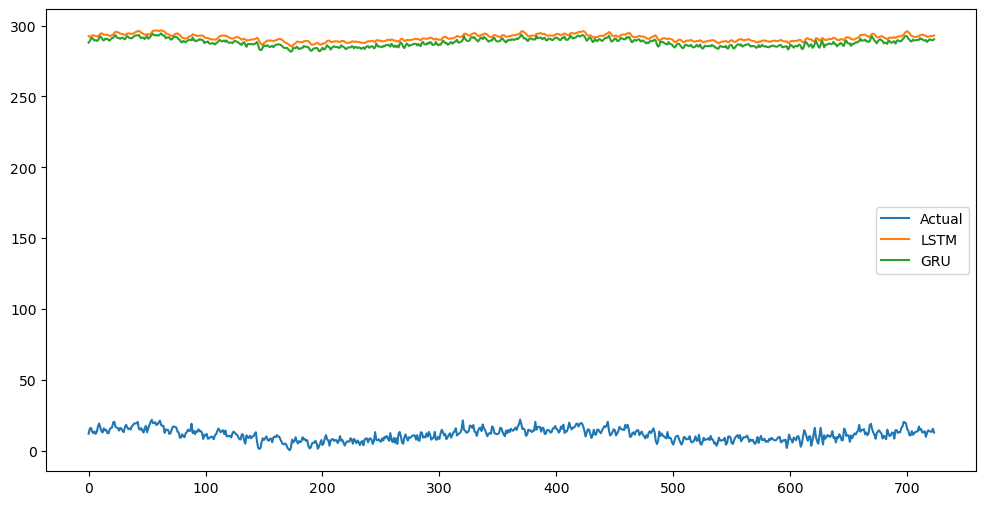

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(actual, label="Actual")

plt.plot(lstm_pred, label="LSTM")

plt.plot(gru_pred, label="GRU")

plt.legend()

plt.show()